In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download ('stopwords')
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
df=pd.read_csv('/content/drive/MyDrive/bank_reviews.csv')
df.head(2)

,author,date,address,bank,rating,review_title_by_user,review,bank_image,rating_title_by_user,useful_count
0,AMRENDRA T,"Mar 21, 2020",New delhi,SBI,4.0,"""Best saving""",State Bank Of India is located nearby in our a...,https://static.bankbazaar.com/images/common/ba...,Great!,133
1,BISHWA,"Mar 20, 2020",Kolkata,SBI,5.0,"""Good service""","I have my salary account in SBI, when I applie...",https://static.bankbazaar.com/images/common/ba...,Blown Away!,89


In [3]:
df.shape

(1000, 10)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

,0
author,4
date,0
address,0
bank,0
rating,0
review_title_by_user,0
review,0
bank_image,0
rating_title_by_user,0
useful_count,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   author                996 non-null    object 
 1   date                  1000 non-null   object 
 2   address               1000 non-null   object 
 3   bank                  1000 non-null   object 
 4   rating                1000 non-null   float64
 5   review_title_by_user  1000 non-null   object 
 6   review                1000 non-null   object 
 7   bank_image            1000 non-null   object 
 8   rating_title_by_user  1000 non-null   object 
 9   useful_count          1000 non-null   int64  
dtypes: float64(1), int64(1), object(8)
memory usage: 78.3+ KB


In [7]:
data=df.iloc[:,4:7]
data.head()

,rating,review_title_by_user,review
0,4.0,"""Best saving""",State Bank Of India is located nearby in our a...
1,5.0,"""Good service""","I have my salary account in SBI, when I applie..."
2,5.0,"""Excellent Service""",I am using Axis bank saving account for the p...
3,5.0,"""Excellent service""",I have my salary bank account in HDFC bank for...
4,5.0,"""Good account""","Close to around 10 years, I am holding this Co..."


In [8]:
def get_sentiment(rating):
  if rating>=4:
    return 'positive'
  elif rating==3:
    return 'neutral'
  else:
    return 'negative'

In [9]:
data['sentiment']=data['rating'].map(get_sentiment)
data.head()

,rating,review_title_by_user,review,sentiment
0,4.0,"""Best saving""",State Bank Of India is located nearby in our a...,positive
1,5.0,"""Good service""","I have my salary account in SBI, when I applie...",positive
2,5.0,"""Excellent Service""",I am using Axis bank saving account for the p...,positive
3,5.0,"""Excellent service""",I have my salary bank account in HDFC bank for...,positive
4,5.0,"""Good account""","Close to around 10 years, I am holding this Co...",positive


In [10]:
data[data['sentiment']=='positive'].head()

,rating,review_title_by_user,review,sentiment
0,4.0,"""Best saving""",State Bank Of India is located nearby in our a...,positive
1,5.0,"""Good service""","I have my salary account in SBI, when I applie...",positive
2,5.0,"""Excellent Service""",I am using Axis bank saving account for the p...,positive
3,5.0,"""Excellent service""",I have my salary bank account in HDFC bank for...,positive
4,5.0,"""Good account""","Close to around 10 years, I am holding this Co...",positive


In [11]:
data[data['sentiment']=='neutral'].head()

,rating,review_title_by_user,review,sentiment
13,3.0,"""Need to improve their service""",Indian Bank cash deposit machine is not conven...,neutral
18,3.0,"""Good""","Since 14 years, I am using Oriental Bank savin...",neutral
28,3.0,"""Need to decrease interest charge""",I have been using saving account with SBI for ...,neutral
37,3.0,"""Need to improve their service """,I am not getting an alert message from CANARA ...,neutral
53,3.0,"""Features are average""",I have been with Standard chartered Bank for p...,neutral


In [12]:
data[data['sentiment']=='negative'].head()

,rating,review_title_by_user,review,sentiment
74,0.5,"""Bad Customer support""",Axis bank has limited options in menu of Custo...,negative
79,2.0,"""Medium""",I am holding a saving account with SBI bank fo...,negative
80,2.0,"""Medium""",I am having a salary account with AXIS bank fo...,negative
115,2.0,"""Need to improve the service""",IDBI bank account benefits are not good hence ...,negative
120,3.5,"""Need to improve mobile app service""",IOB mobile app is not much user friendly to ac...,negative


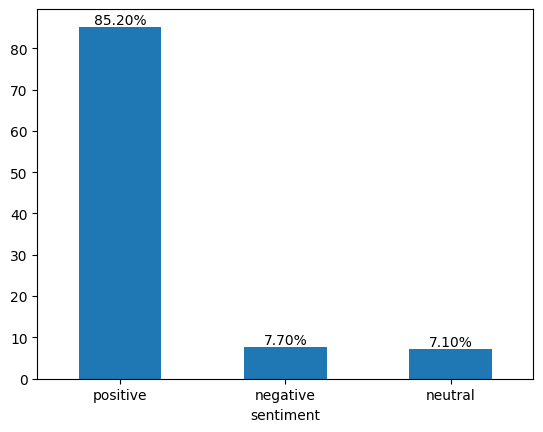

In [13]:
fg=round(data['sentiment'].value_counts(normalize=True)*100,2).plot.bar()
fg.bar_label(fg.containers[0], fmt='%.2f%%')
plt.xticks(rotation=0)
plt.show()

In [14]:
cv=CountVectorizer(stop_words='english')
words=cv.fit_transform(data['review'])
sum_words=words.sum(axis=0)
word_freq=[(word, sum_words[0, i]) for word, i in cv.vocabulary_.items()]
word_freq=sorted(word_freq, key=lambda x:x[1], reverse=True)
frequency=pd.DataFrame(word_freq, columns=['word', 'count'])
frequency.head()

,word,count
0,account,1910
1,bank,1242
2,balance,743
3,banking,693
4,service,680


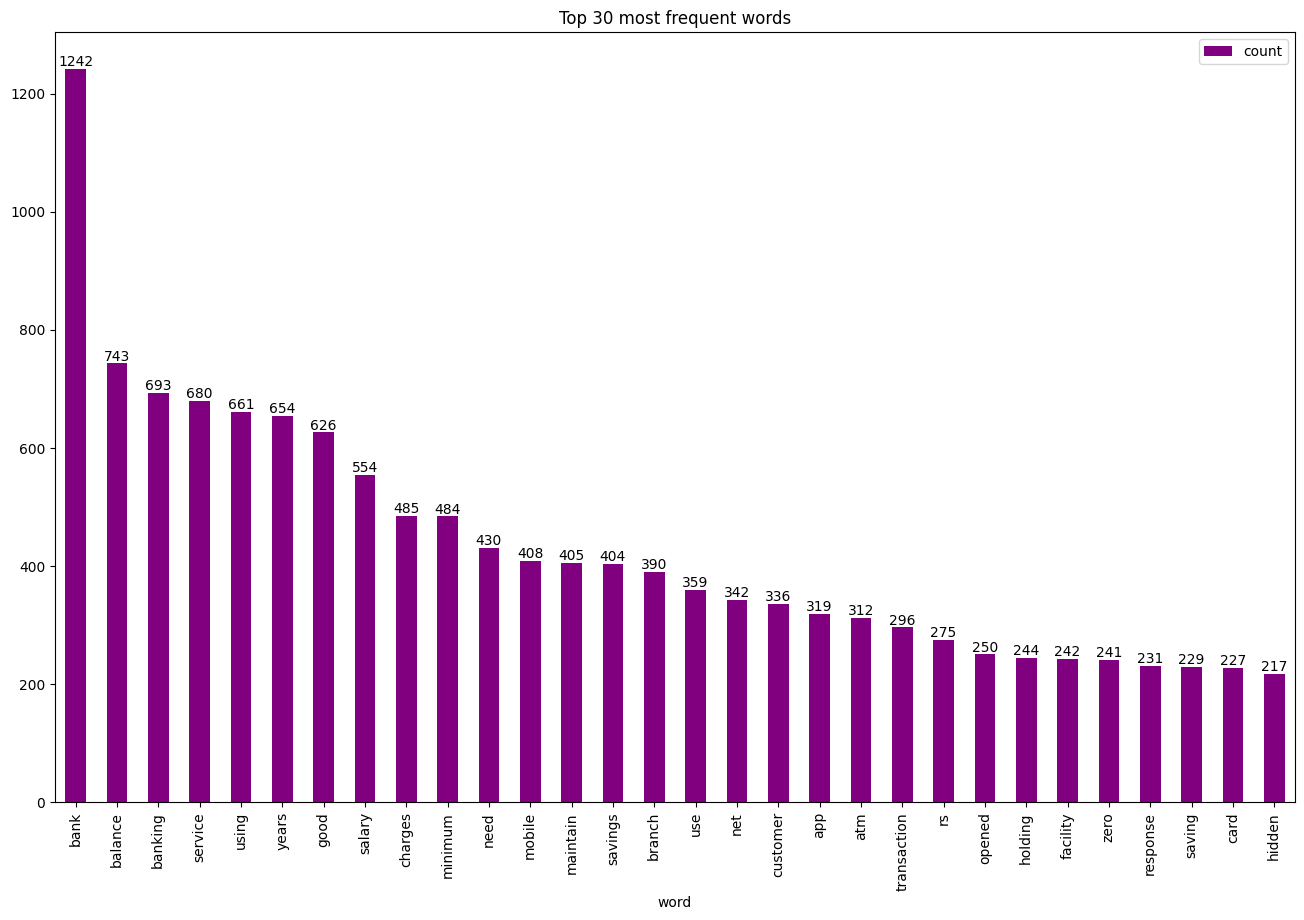

In [15]:
freq_plot=frequency.loc[1:30].plot(x='word', y='count', kind='bar', figsize=(16,10), color='purple')
freq_plot.bar_label(freq_plot.containers[0])
plt.title("Top 30 most frequent words")
plt.show()

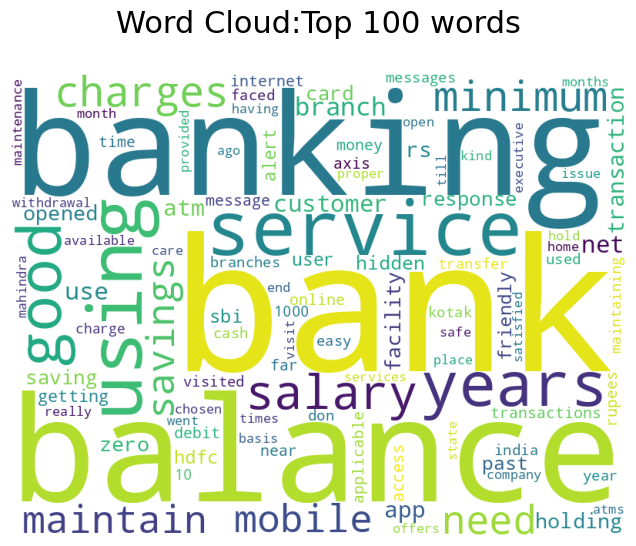

In [16]:
wc_plot=WordCloud(background_color='white', width=800, height=600).generate_from_frequencies(dict(word_freq[1:100]))
plt.figure(figsize=(10,6))
plt.title("Word Cloud:Top 100 words\n", fontsize=22)
plt.imshow(wc_plot)
plt.axis('off')
plt.show()

In [17]:
train_corpus=[]
for i in range(0, len(data)):
  review=re.sub('[^a-zA-Z\s]', '', data['review'][i])
  review=review.lower()
  review=review.split()
  ps=PorterStemmer().stem
  review=[ps(word) for word in review if word not in stopwords.words('english')]
  review=' '.join(review)
  train_corpus.append(review)

In [18]:
vectorizer=TfidfVectorizer(max_features=3000, min_df=3, max_df=0.9, ngram_range=(1,2))
x=vectorizer.fit_transform(train_corpus).toarray()
y=data['sentiment']

In [19]:
y.value_counts(normalize=True)*100

,proportion
sentiment,
positive,85.2
negative,7.7
neutral,7.1


In [20]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [21]:
param_grid={'C':[0.1,0.5,0.8,1],
            'penalty':['l2'],
            'solver':['lbfgs']}

In [22]:
grid=GridSearchCV(LogisticRegression(max_iter=200, class_weight='balanced', multi_class='multinomial'), param_grid, cv=5,
                  scoring='f1_weighted')
grid.fit(x_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.8093017216287116


In [23]:
best_model=grid.best_estimator_
y_pred=best_model.predict(x_test)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred),2))

Test Accuracy: 0.79


In [24]:
scores=cross_val_score(best_model, x_train, y_train)
print("Cross validation score:", scores)
print("Mean CV score:", round(scores.mean(),2))

Cross validation score: [0.7875  0.80625 0.83125 0.81875 0.81875]
Mean CV score: 0.81


In [25]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

    negative       0.27      0.25      0.26        16
     neutral       0.15      0.21      0.18        14
    positive       0.91      0.88      0.90       170

    accuracy                           0.79       200
   macro avg       0.44      0.45      0.44       200
weighted avg       0.80      0.79      0.79       200



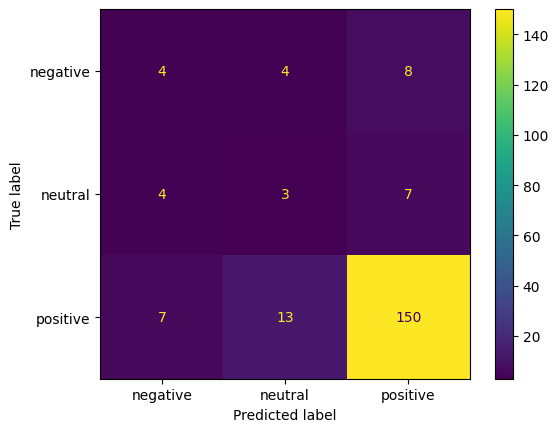

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [27]:
ros=RandomOverSampler()
x_resampled, y_resampled=ros.fit_resample(x_train, y_train)
mnb=MultinomialNB()
mnb.fit(x_resampled, y_resampled)


MultinomialNB()

In [28]:
y_pred_mnb=mnb.predict(x_test)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_mnb),2))

Test Accuracy: 0.7


In [29]:
print("Classification Report:\n", classification_report(y_test, y_pred_mnb))

Classification Report:
               precision    recall  f1-score   support

    negative       0.20      0.25      0.22        16
     neutral       0.11      0.29      0.16        14
    positive       0.92      0.78      0.84       170

    accuracy                           0.70       200
   macro avg       0.41      0.44      0.41       200
weighted avg       0.80      0.70      0.74       200



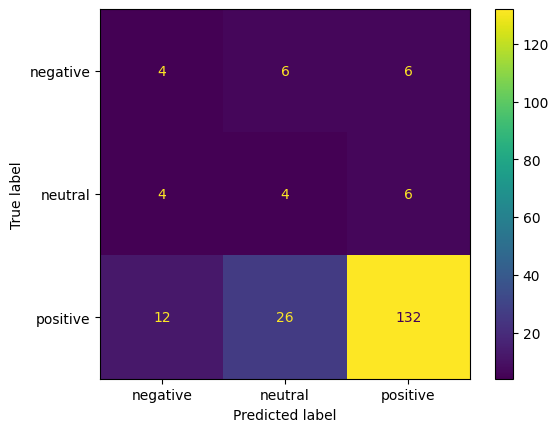

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mnb)
plt.show()

In [31]:
svc=LinearSVC(class_weight='balanced')
svc.fit(x_train, y_train)

LinearSVC(class_weight='balanced')

In [32]:
y_pred_svc=svc.predict(x_test)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_svc),2))

Test Accuracy: 0.85


In [33]:
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

Classification Report:
               precision    recall  f1-score   support

    negative       0.43      0.19      0.26        16
     neutral       0.40      0.14      0.21        14
    positive       0.88      0.97      0.92       170

    accuracy                           0.85       200
   macro avg       0.57      0.43      0.46       200
weighted avg       0.81      0.85      0.82       200



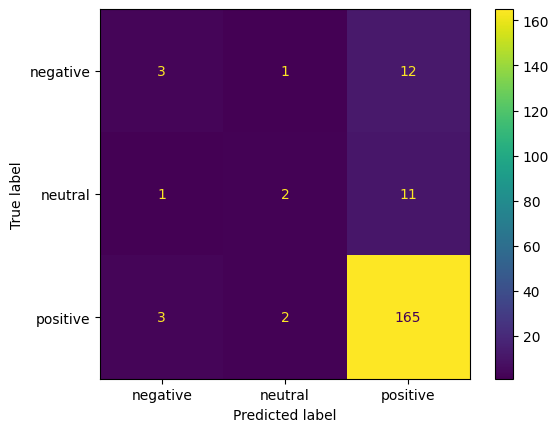

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc)
plt.show()